In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from hierarchical_clustering_invariant import *
from sklearn.metrics import pairwise_distances

In [53]:
def generate_3cluster_data(n=30, p=2, delta=3.0, sigma=1.0, random_state=None):
    rng = np.random.default_rng(random_state)
    n_cluster = n // 3
    mu1 = np.zeros(p)
    mu1[0] = -delta / 2
    mu2 = np.zeros(p)
    mu2[-1] = np.sqrt(3) * delta / 2
    mu3 = np.zeros(p)
    mu3[0] = delta / 2

    X1 = rng.normal(loc=mu1, scale=sigma, size=(n_cluster, p))
    X2 = rng.normal(loc=mu2, scale=sigma, size=(n_cluster, p))
    X3 = rng.normal(loc=mu3, scale=sigma, size=(n_cluster, p))
    X = np.vstack([X1, X2, X3])
    return X

def generate_3cluster_data_varsize(n=50, p=2, delta=1.0, sigma=1.0,
                                   cluster_sizes=None, random_state=None, return_labels=True):
    rng = np.random.default_rng(random_state)

    # handle cluster sizes
    if cluster_sizes is None:
        if n % 3 != 0:
            raise ValueError("If cluster_sizes is None, n must be divisible by 3.")
        cluster_sizes = (n // 3, n // 3, n // 3)
    else:
        if len(cluster_sizes) != 3:
            raise ValueError("cluster_sizes must be a tuple/list of 3 integers.")
        if sum(cluster_sizes) != n:
            raise ValueError(f"sum(cluster_sizes)={sum(cluster_sizes)} must equal n={n}.")

    # define means (equilateral triangle in 2D, generalized in higher dimensions)
    mu1 = np.zeros(p)
    mu1[0] = -delta / 2

    mu2 = np.zeros(p)
    mu2[-1] = np.sqrt(3) * delta / 2

    mu3 = np.zeros(p)
    mu3[0] = delta / 2

    X1 = rng.normal(loc=mu1, scale=sigma, size=(cluster_sizes[0], p))
    X2 = rng.normal(loc=mu2, scale=sigma, size=(cluster_sizes[1], p))
    X3 = rng.normal(loc=mu3, scale=sigma, size=(cluster_sizes[2], p))

    X = np.vstack([X1, X2, X3])
    labels = np.array([0]*cluster_sizes[0] + [1]*cluster_sizes[1] + [2]*cluster_sizes[2])

    if return_labels:
        return X, labels
    else:
        return X

def compute_gap_hclust(X, K_max=8, B=20, method="complete", random_state=None):
    rng = np.random.default_rng(random_state)
    n, p = X.shape
    mins, maxs = X.min(axis=0), X.max(axis=0)

    def wcss(X, labels):
        """Within-cluster sum of squares"""
        return np.sum([
            np.sum((X[labels == k] - X[labels == k].mean(axis=0)) ** 2)
            for k in np.unique(labels)
        ])

    log_Wk = []
    log_Wk_star = np.zeros((B, K_max))

    # --- Step 1: Compute observed Wk ---
    Z = linkage(X, method=method)
    for k in range(1, K_max + 1):
        labels = fcluster(Z, k, criterion="maxclust")
        log_Wk.append(np.log(wcss(X, labels)))

    # --- Step 2: Compute reference Wk* ---
    for b in range(B):
        Xb = rng.uniform(mins, maxs, size=(n, p))
        Zb = linkage(Xb, method=method)
        for k in range(1, K_max + 1):
            labels_b = fcluster(Zb, k, criterion="maxclust")
            log_Wk_star[b, k - 1] = np.log(wcss(Xb, labels_b))

    # --- Step 3: Compute Gap statistic ---
    gap = np.mean(log_Wk_star, axis=0) - np.array(log_Wk)
    sdk = np.sqrt(1 + 1 / B) * np.std(log_Wk_star, axis=0)

    # --- Step 4: Choose optimal K (Tibshirani rule) ---
    K_hat = None
    for k in range(1, K_max):  # up to K_max-1
        if gap[k - 1] >= gap[k] - sdk[k]:
            K_hat = k
            break
    if K_hat is None:
        K_hat = K_max  # if never satisfied, choose largest K

    return np.arange(1, K_max + 1), gap, sdk, K_hat
def find_best_K_F(X, tau, alpha_list, n_threshold=2, linkage="complete", total_alpha=0.05):
    n = np.shape(X)[0]
    if not np.isclose(np.sum(alpha_list), total_alpha):
        raise ValueError(
            f"Alpha list should sum up to total alpha = {total_alpha}, " 
            f"but got {np.sum(alpha_list):.4f} instead.")
    if len(alpha_list) != (n - 1):
        raise ValueError("The length of alpha_list should be equal to n - 1.")

    p_values = []
    alpha_seq = []
    K_hat = 1

    model = AgglomerativeClustering(X, tau=tau, n_clusters=1, linkage=linkage)
    model.fit()
    winning_nodes = list(model.existing_clusters_log.keys())  # to get all merges

    for t, winning_pair in enumerate(winning_nodes):
        node1, node2 = winning_pair
        node = node1.parent
        n1, n2 = len(node1.points), len(node2.points)

        if (1 / n1 + 1 / n2) >= n_threshold:
            alpha = np.min(alpha_list)  # conservative for smaller clusters
            idx = np.argmin(alpha_list)
            if (n1 + n2) == 2:
                pval = 1  # edge case
            else:
                pval, _, _ = model.merge_inference_F_grid(node, grid_width=180, ncoarse=50, ngrid=1000)
        else:
            alpha = np.max(alpha_list)  # more power for larger clusters
            idx = np.argmax(alpha_list)
            pval, _, _ = model.merge_inference_F_grid(node, grid_width=180, ncoarse=50, ngrid=1000)

        alpha_list = np.delete(alpha_list, idx)
        alpha_seq.append(alpha)
        p_values.append(pval)

        if pval < alpha:
            K_hat = n - t
            return (K_hat, p_values, alpha_seq, model)

    return (K_hat, p_values, alpha_seq, model)

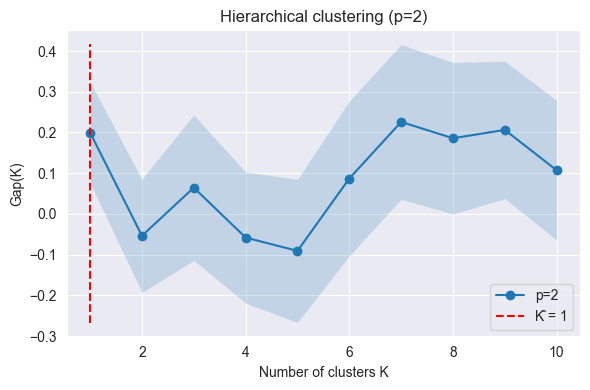

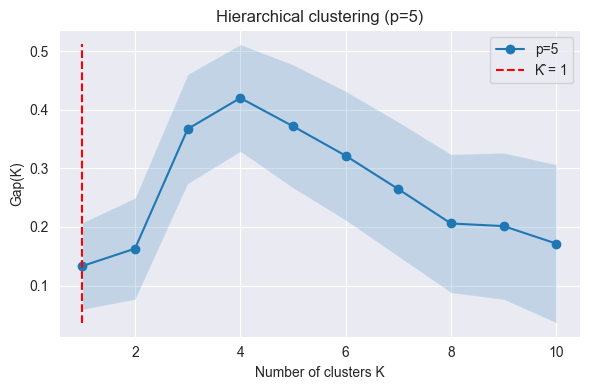

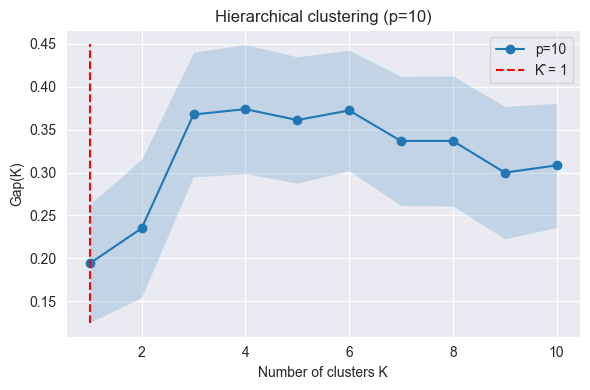

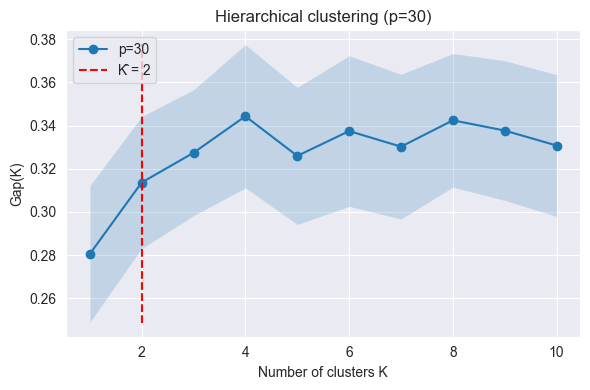

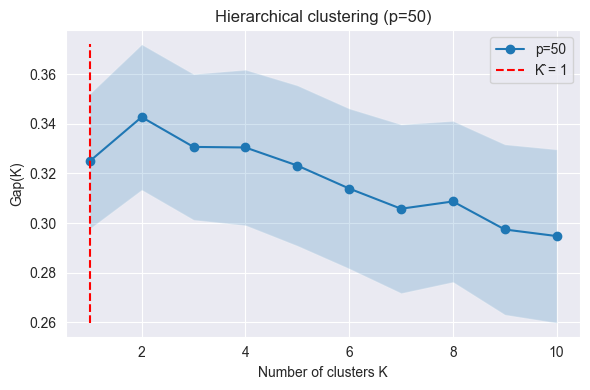

In [62]:
for p in [2,5,10, 30,50]:
    X,label = generate_3cluster_data_varsize(n=30, p=p, delta=4.0, sigma=1.0,cluster_sizes=[10,10,10])
    K, gap, sdk, K_hat = compute_gap_hclust(X, K_max=10, B=50, method="complete")

    plt.figure(figsize=(6, 4))
    plt.plot(K, gap, marker="o", label=f"p={p}")
    plt.fill_between(K, gap - sdk, gap + sdk, alpha=0.2)
    plt.vlines(K_hat, ymin=min(gap - sdk), ymax=max(gap + sdk),
               colors="red", linestyles="--", label=f"K̂ = {K_hat}")
    plt.xlabel("Number of clusters K")
    plt.ylabel("Gap(K)")
    plt.title(f"Hierarchical clustering (p={p})")
    plt.legend()
    plt.tight_layout()
    plt.show()

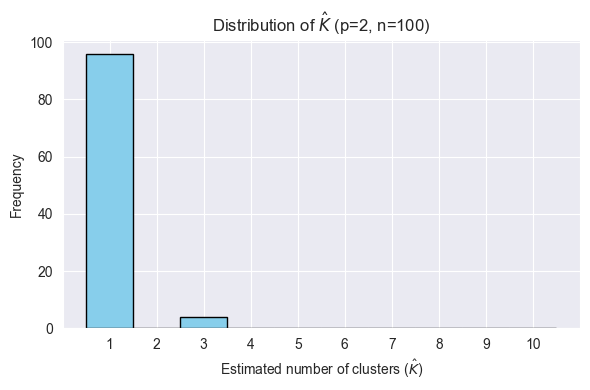

p = 2
  K̂ = 1: 0.96
  K̂ = 3: 0.04
----------------------------------------


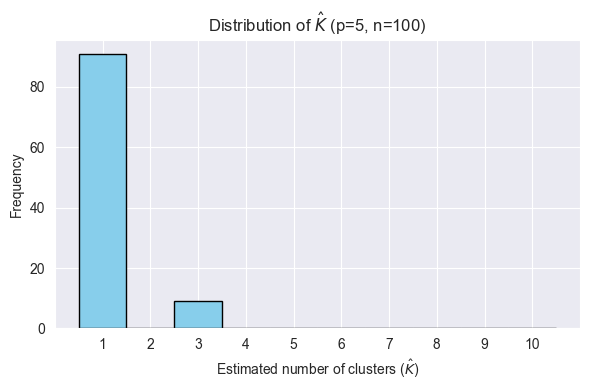

p = 5
  K̂ = 1: 0.91
  K̂ = 3: 0.09
----------------------------------------


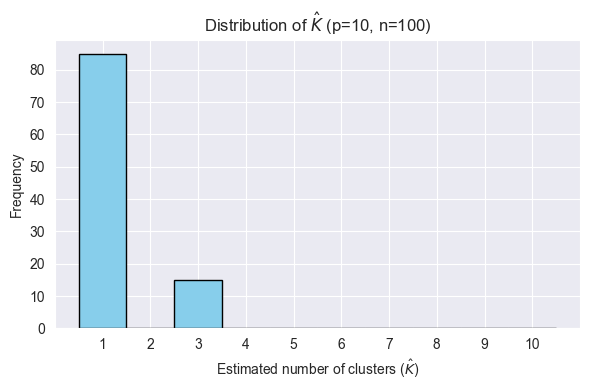

p = 10
  K̂ = 1: 0.85
  K̂ = 3: 0.15
----------------------------------------


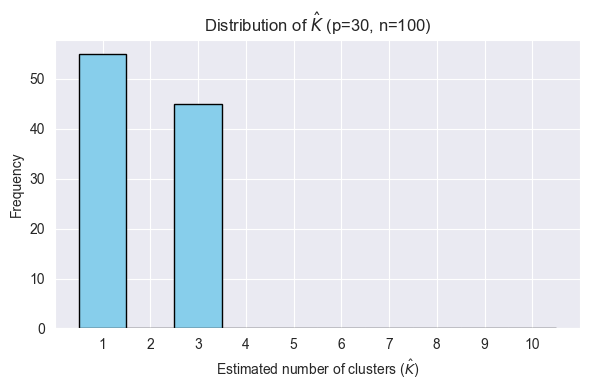

p = 30
  K̂ = 1: 0.55
  K̂ = 3: 0.45
----------------------------------------


In [56]:
from collections import Counter
from find_best_K import find_best_K_F
num_trials = 100
p_list = [2, 5, 10, 30]
Khat_results = {}
Khat_F_results = {}
n=30
total_alpha = 0.05
alpha_list = np.full(n - 1, total_alpha / (n - 1))
for p in p_list:
    Khat_list = []
    Khat_F_list = []
    for t in range(num_trials):
        X = generate_3cluster_data(n=15, p=p, delta=8.0, sigma=1.0, random_state=t)
        _, _, _, K_hat = compute_gap_hclust(X, K_max=10, B=50, method="complete", random_state=t+1000)
        #K_hat_F, _, _,_ = find_best_K_F(X, tau=0.1, alpha_list=alpha_list, total_alpha=total_alpha)
        Khat_list.append(K_hat)
        #Khat_F_list.append(K_hat_F)
    Khat_results[p] = Khat_list
    #Khat_F_results[p] = Khat_F_list
    # Plot histogram for each p
    plt.figure(figsize=(6, 4))
    plt.hist(Khat_list, bins=np.arange(1, 12)-0.5, edgecolor="black", color="skyblue")
    #plt.hist(Khat_F_list, bins=np.arange(1, 12)-0.5, edgecolor="black", color="green")
    plt.xticks(range(1, 11))
    plt.xlabel("Estimated number of clusters ($\hat{K}$)")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of $\hat{{K}}$ (p={p}, n={num_trials})")
    plt.tight_layout()
    plt.show()

    # Print summary
    counts = Counter(Khat_list)
    #counts_F = Counter(Khat_F_list)
    print(f"p = {p}")
    for k, c in sorted(counts.items()):
        print(f"  K̂ = {k}: {c/num_trials:.2f}")
    #for k, c in sorted(counts_F.items()):
    #    print(f"  K̂ = {k}: {c/num_trials:.2f}")
    print("-"*40)


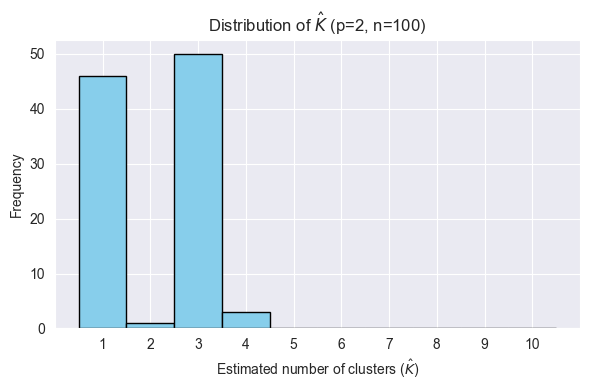

p = 2
  K̂ = 1: 0.46
  K̂ = 2: 0.01
  K̂ = 3: 0.50
  K̂ = 4: 0.03
----------------------------------------


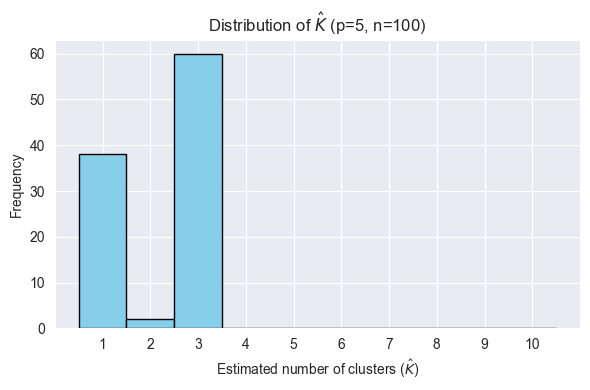

p = 5
  K̂ = 1: 0.38
  K̂ = 2: 0.02
  K̂ = 3: 0.60
----------------------------------------


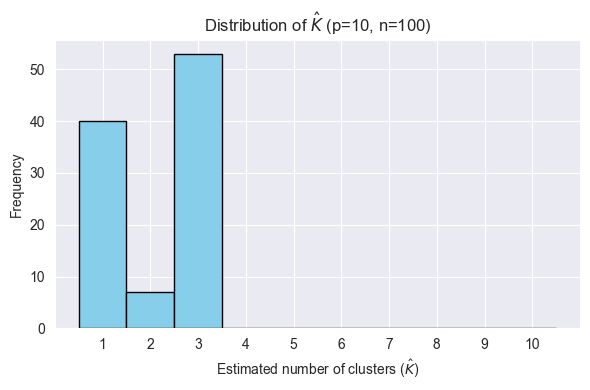

p = 10
  K̂ = 1: 0.40
  K̂ = 2: 0.07
  K̂ = 3: 0.53
----------------------------------------


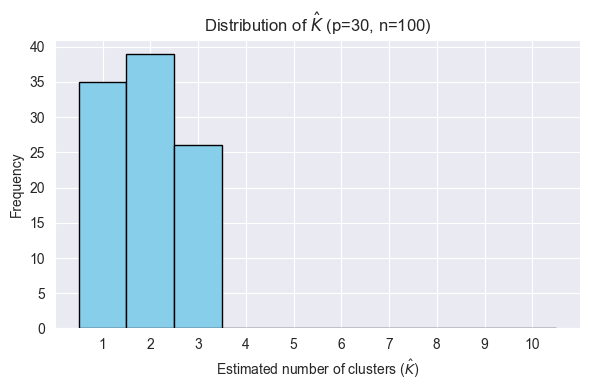

p = 30
  K̂ = 1: 0.35
  K̂ = 2: 0.39
  K̂ = 3: 0.26
----------------------------------------


In [57]:
from collections import Counter
from find_best_K import find_best_K_F
num_trials = 100
p_list = [2, 5, 10, 30]
Khat_results = {}
Khat_F_results = {}
n=30
total_alpha = 0.05
alpha_list = np.full(n - 1, total_alpha / (n - 1))
for p in p_list:
    Khat_list = []
    Khat_F_list = []
    for t in range(num_trials):
        X,y = generate_3cluster_data_varsize(n=15, p=p, delta=8.0, sigma=1.0,cluster_sizes=[10,3,2], random_state=t)
        _, _, _, K_hat = compute_gap_hclust(X, K_max=10, B=50, method="complete", random_state=t+1000)
        #K_hat_F, _, _,_ = find_best_K_F(X, tau=0.1, alpha_list=alpha_list, total_alpha=total_alpha)
        Khat_list.append(K_hat)
        #Khat_F_list.append(K_hat_F)
    Khat_results[p] = Khat_list
    #Khat_F_results[p] = Khat_F_list
    # Plot histogram for each p
    plt.figure(figsize=(6, 4))
    plt.hist(Khat_list, bins=np.arange(1, 12)-0.5, edgecolor="black", color="skyblue")
    #plt.hist(Khat_F_list, bins=np.arange(1, 12)-0.5, edgecolor="black", color="green")
    plt.xticks(range(1, 11))
    plt.xlabel("Estimated number of clusters ($\hat{K}$)")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of $\hat{{K}}$ (p={p}, n={num_trials})")
    plt.tight_layout()
    plt.show()

    # Print summary
    counts = Counter(Khat_list)
    #counts_F = Counter(Khat_F_list)
    print(f"p = {p}")
    for k, c in sorted(counts.items()):
        print(f"  K̂ = {k}: {c/num_trials:.2f}")
    #for k, c in sorted(counts_F.items()):
    #    print(f"  K̂ = {k}: {c/num_trials:.2f}")
    print("-"*40)
